#Import Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load The Dataset

In [3]:
sensor_df = pd.read_csv("ops_sensor_log_dirty.csv")

#Basic Dataset Information

In [4]:
sensor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   object 
 1   Zone           4984 non-null   object 
 2   Shift          4962 non-null   object 
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), object(3)
memory usage: 235.2+ KB


#Statistical Summary

In [5]:
sensor_df.describe(include='all')

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,5015,4984,4962,4975.000000,4975.000000,4966.000000
unique,5000,15,3,NaN,NaN,NaN
top,2026-06-29 09:24:00,Zone_Central,Afternoon,NaN,NaN,NaN
freq,2,996,1715,NaN,NaN,NaN
mean,NaN,NaN,NaN,255.254281,68.982323,999.275681
std,NaN,NaN,NaN,845.810206,78.829078,231.769525
min,NaN,NaN,NaN,-50.000000,-273.150000,600.007437
25%,NaN,NaN,NaN,160.753008,55.023155,797.417014
50%,NaN,NaN,NaN,200.294439,64.808608,996.286415
75%,NaN,NaN,NaN,240.099173,74.527006,1201.361276


#Check Missing Values

In [6]:
sensor_df.isnull().sum()

timestamp         0
Zone             31
Shift            53
Pressure_PSI     40
Temperature_C    40
Flow_Rate_LPM    49
dtype: int64

#Check Duplicate Rows

In [7]:
sensor_df.duplicated().sum()

np.int64(15)

#Check Data Types

In [8]:
print(sensor_df.dtypes)

timestamp         object
Zone              object
Shift             object
Pressure_PSI     float64
Temperature_C    float64
Flow_Rate_LPM    float64
dtype: object


#Data Health Report

##Data Set Overview
-Total Rows:
-Total Columns:

##Quality Issues Identified
1. Missing Values

Several columns contain missing values that could affect analysis and model accuracy.

Column	Missing Values
Shift	53
Flow_Rate_LPM	49
Pressure_PSI	40
Temperature_C	40
Zone	31

Impact:

Incomplete records may produce inaccurate statistics and visualizations.
Missing sensor readings can distort trend analysis.

2. Duplicate Records

The dataset contains 15 duplicate rows.

Impact:

Duplicate observations can bias averages and aggregations.
May result in incorrect operational metrics and reporting.

3. Invalid / Extreme Sensor Readings (Outliers)

Several values fall outside realistic operating ranges.

Temperature_C
Minimum: -273.15°C
Maximum: 1500°C

These values are physically unrealistic for normal industrial operations and likely represent sensor errors or data-entry issues.

Pressure_PSI

Minimum: -50 PSI
Maximum: 15,000 PSI

Negative pressure values and extremely high pressures suggest faulty readings or data corruption.

Impact:

Outliers can heavily skew means, standard deviations, and visualizations.
Can mislead operational decision-making if not treated.

#Cleaning Pipeline
#A reusable function clean_ops_data(df)


#Converts timestamps to datetime objects.

In [9]:
def clean_ops_data(df):
    """
    Convert timestamp column to datetime format.
    """

    df = df.copy()


    df['timestamp'] = pd.to_datetime(
        df['timestamp'],
        errors='coerce'
    )

    return df

#Handles missing values (justify your choice: drop, fill, or interpolate).

In [11]:
def clean_ops_data(df):

    df = df.copy()


    df['Zone'] = df['Zone'].fillna(df['Zone'].mode()[0])
    df['Shift'] = df['Shift'].fillna(df['Shift'].mode()[0])


    df['Pressure_PSI'] = df['Pressure_PSI'].interpolate(method='linear')
    df['Temperature_C'] = df['Temperature_C'].interpolate(method='linear')
    df['Flow_Rate_LPM'] = df['Flow_Rate_LPM'].interpolate(method='linear')

    return df

#Removes duplicates.

In [12]:
def clean_ops_data(df):

    df = df.copy()

    df = df.drop_duplicates()

    return df

#Standardizes categorical columns (e.g., location names).

In [13]:
def clean_ops_data(df):

    df = df.copy()

    df['Zone'] = df['Zone'].str.strip().str.upper()
    df['Shift'] = df['Shift'].str.strip().str.upper()

    return df

#Filters out physically impossible sensor readings (outliers).

In [14]:
def clean_ops_data(df):

    df = df.copy()

    df = df[
        (df['Temperature_C'] >= -40) &
        (df['Temperature_C'] <= 100)
    ]

    df = df[
        (df['Pressure_PSI'] >= 0) &
        (df['Pressure_PSI'] <= 500)
    ]

    df = df[
        (df['Flow_Rate_LPM'] >= 0) &
        (df['Flow_Rate_LPM'] <= 1000)
    ]

    return df

# Time-Series Analysis: 
#Resample the cleaned data to an hourly frequency

In [16]:
clean_df = clean_ops_data(sensor_df)

In [17]:
import pandas as pd

sensor_df = pd.read_csv("ops_sensor_log_dirty.csv")

In [19]:
def clean_ops_data(df):
    return df

In [21]:
clean_df = clean_ops_data(sensor_df)

#Set Timestamp as the Index

In [25]:
print(clean_df.columns.tolist())
print(clean_df.index.name)

['Zone', 'Shift', 'Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM']
timestamp


In [27]:
clean_df.index = pd.to_datetime(clean_df.index)

In [28]:
# Sort by time
clean_df = clean_df.sort_index()

# Hourly average pressure
hourly_pressure = clean_df['Pressure_PSI'].resample('h').mean()

# 24-hour rolling average
pressure_24hr_roll = hourly_pressure.rolling(window=24).mean()

print(pressure_24hr_roll.head())

timestamp
2026-01-07 09:00:00   NaN
2026-01-07 10:00:00   NaN
2026-01-07 11:00:00   NaN
2026-01-07 12:00:00   NaN
2026-01-07 13:00:00   NaN
Freq: h, Name: Pressure_PSI, dtype: float64


#Aggregation

In [29]:
shift_summary = clean_df.groupby('Shift')['Pressure_PSI'].agg(
    Mean='mean',
    Max='max',
    Min='min'
)

print(shift_summary)

                 Mean      Max   Min
Shift                               
Afternoon  252.044273  15000.0 -50.0
Morning    228.062158  15000.0 -50.0
Night      278.567510  15000.0 -50.0


In [30]:
zone_summary = clean_df.groupby('Zone')['Pressure_PSI'].agg(
    Mean='mean',
    Max='max',
    Min='min'
)

print(zone_summary)

                    Mean           Max         Min
Zone                                              
 North Zone   216.616830    277.069521  135.049571
 South Zone   226.042318    273.821195  188.030301
ZONE-NORTH    175.434553    270.088617  -50.000000
ZONE_SOUTH    203.494875    279.108960  142.493573
Zone_Central  238.720588  15000.000000  -50.000000
Zone_East     272.111360  15000.000000  -50.000000
Zone_North    235.191608  15000.000000  -50.000000
Zone_North    194.329058    260.748913  132.158961
Zone_South    270.897538  15000.000000  -50.000000
Zone_South    225.260229    278.702857  186.434201
Zone_West     266.638518  15000.000000  -50.000000
z_north       205.368140    261.683814  141.355021
z_south       202.608392    275.888794  126.129195
zone north    204.153782    275.115651  125.928319
zone south    202.439312    279.432081  150.103508


#Visualization: Raw vs Clean Data

In [36]:
print("Raw rows:", len(sensor_df))
print("Clean rows:", len(clean_df))
print("Rows removed:", len(sensor_df) - len(clean_df))

Raw rows: 5015
Clean rows: 5015
Rows removed: 0


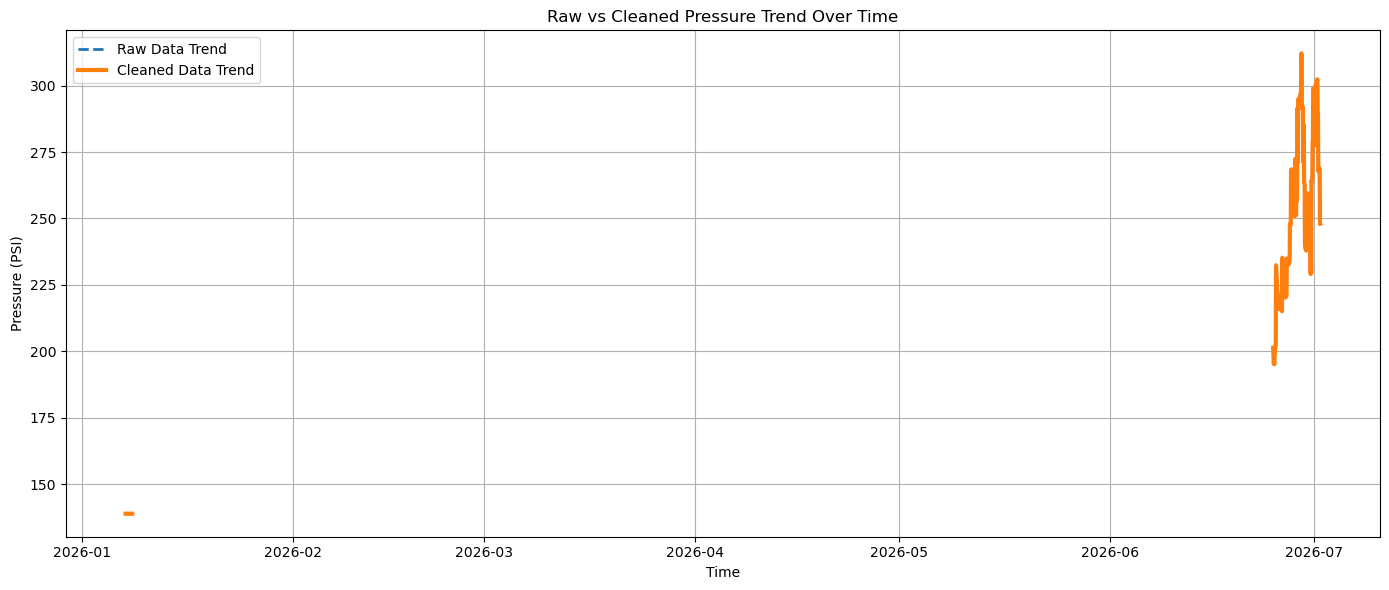

In [ ]:


# Raw data
sensor_df['timestamp'] = pd.to_datetime(sensor_df['timestamp'], errors='coerce')
raw_plot = sensor_df.set_index('timestamp').sort_index()

# Cleaned data
clean_plot = clean_df.copy()
clean_plot.index = pd.to_datetime(clean_plot.index)
clean_plot = clean_plot.sort_index()

# Create hourly averages
raw_hourly = raw_plot['Pressure_PSI'].resample('h').mean()
clean_hourly = clean_plot['Pressure_PSI'].resample('h').mean()

# Create rolling averages
raw_trend = raw_hourly.rolling(window=24, min_periods=1).mean()
clean_trend = clean_hourly.rolling(window=24, min_periods=1).mean()

# Plot
plt.figure(figsize=(14,6))

plt.plot(raw_trend.index,
         raw_trend,
         linestyle='--',
         linewidth=2,
         label='Raw Data Trend')

plt.plot(clean_trend.index,
         clean_trend,
         linewidth=3,
         label='Cleaned Data Trend')

plt.title('Raw vs Cleaned Pressure Trend Over Time')
plt.xlabel('Time')
plt.ylabel('Pressure (PSI)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()